In [34]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.special import factorial
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import math

Important constants

In [35]:
c=2.998*10**8
v_esc = 500*10**3/c
v_E = 240*1000/c
w_minus = 60*10**-3
w_plus = 20*10**-3
v0 = 230*1000/c
ratio=v_esc/v0
N0 = v0**3*np.pi*(np.sqrt(np.pi)*scipy.special.erf(ratio)-2*ratio*np.exp(-ratio**2))
dm_density = 0.4 #GeV/cm^3, plus minus 0.1
target_density = 1.31e24 #GeV/cm^3
Si_nucleus_mass = 931368088 #eV
f=1
V=1

In [36]:
def reducedMass(m1, m2):
    return m1*m2/(m1+m2)

Inverse Mean Function from v_min input as well as its helper functions

In [37]:
def inverseMeanFunction_sol1(v_min, m_chi, const):
    summ = np.sqrt(np.pi)*v0*(scipy.special.erf((v_min+v_E)/v0)-scipy.special.erf((v_min-v_E)/v0))
    summ -= 4*np.exp(-v_esc**2/v0**2)*v_E
    return summ*const

In [38]:
def inverseMeanFunction_sol2(v_min, m_chi, const):
    summ = np.sqrt(np.pi)*v0*(scipy.special.erf(v_esc/v0)-scipy.special.erf((v_min-v_E)/v0))
    summ -= 2*np.exp(-v_esc**2/v0**2)*(v_esc-v_min+v_E)
    return summ*const

In [39]:
def inverseMeanFunction(v_min, m_chi, const = v0**2*np.pi/(2*v_E*N0)):
    """
    Returns the inverse mean value for any given v_min.  
    Parameters:
        v_min: input velocity
        m_chi: mass of dark matter
        const: scaling value for graphing.  As a default, it gives the true scale of the equation
    """
    if v_min>v_esc+v_E:
        return 0
    elif v_min>v_esc-v_E:
        return inverseMeanFunction_sol2(v_min,m_chi, const)
    else: 
        return inverseMeanFunction_sol1(v_min,m_chi, const)

In [40]:
def getOmega(n,j):
    return n*w_minus+j*(w_plus-w_minus)

The following graphs the inverse mean speed as a function of v_min.  The vertical lines show the boundaries of the piecewise function.  First line is for the true minimum velocity.  Middle line is the cutoff between the two non-zero functions.  It equals v_esc-v_E.  The final line shows when the function goes to 0

In [41]:
vmin = np.linspace(0.01*v_E, v_esc+v_E*1.3, 100)

In [42]:
y = [inverseMeanFunction(v, v0**2*np.pi/(2*v_E*N0)) for v in vmin]

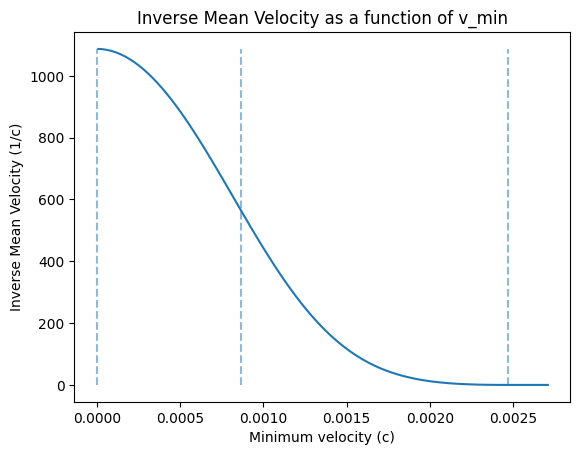

In [43]:
plt.plot(vmin, y)
plt.vlines([0, v_esc-v_E, v_esc+v_E], 0,max(y), linestyles="dashed", alpha=0.5)
plt.title("Inverse Mean Velocity as a function of v_min")
plt.ylabel("Inverse Mean Velocity (1/c)")
plt.xlabel("Minimum velocity (c)")
plt.show()

Inverse mean function from q input as well as its helper function

In [44]:
def get_vmin(q,w, m_chi):
    return w/q+q/(2*m_chi)

In [45]:
def inverseMeanFunction_fromq(q, w, m_chi, const=v0**2*np.pi/(2*v_E*N0)):
    return inverseMeanFunction(get_vmin(q,w,m_chi), m_chi, const)

Graph of the inverse mean speed function with q as its input.  

In [46]:
m_chi = 20000
w = 0.01
q_range = np.linspace(1, m_chi*(v_esc+v_E)+np.sqrt(m_chi**2*(v_esc+v_E)**2)+10, 200)
y = [inverseMeanFunction_fromq(q, w, m_chi) for q in q_range]

Inverse Mean Velocity as a function of q


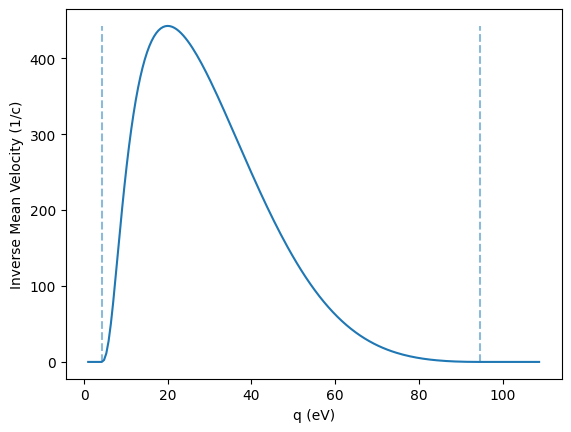

In [47]:
plt.plot(q_range, y)
plt.vlines([m_chi*(v_esc+v_E)-np.sqrt(m_chi**2*(v_esc+v_E)**2-2*w*m_chi), 
            m_chi*(v_esc+v_E)+np.sqrt(m_chi**2*(v_esc+v_E)**2-2*w*m_chi)],0,max(y), linestyles="dashed", alpha=0.5)
plt.ylabel("Inverse Mean Velocity (1/c)")
plt.xlabel("q (eV)")
print("Inverse Mean Velocity as a function of q")

In [48]:
def get_diag(n,j,q, m, w1, w2): 
    debye_waller = q**2 / (8*m) * (1/w1 +1/w2)
    return np.exp(-2*debye_waller) * (q**2/(4*m))**n / (math.factorial(j) * math.factorial(n-j) * (w1**j) * (w2**(n-j)))

def get_off_diag(n,j,q, m, w1, w2, a=0.543*5.064225): 
    debye_waller = q**2 / (8*m) * (1/w1 +1/w2)
    return (-1**(n-j)) * np.exp(-2*debye_waller) * np.cos(q*a) * (q**2/(4*m))**n / (math.factorial(j) * math.factorial(n-j) * (w1**j) * (w2**(n-j)))

In [49]:
def structure_factor_and_inverse_mean(q,n,j,m, const = v0**2*np.pi/(2*v_E*N0)):
    w_curr = n*w_minus+j*(w_plus-w_minus)
    result=get_diag(n,j,q, m, w_plus, w_minus)+get_off_diag(n,j,q, m, w_plus, w_minus)
    result = result*inverseMeanFunction_fromq(q, w_curr, m, const)
    return result

In [50]:
def findMax_n(m_chi):
    return int(m_chi*(v_esc+v_E)**2/(2*w_minus))

In [51]:
def scatteringRate_derivative_wrtq(q, m_chi, cross_section, prop=1, n_max=5):
    mu_X = reducedMass(m_chi, Si_nucleus_mass)
    const=dm_density/(target_density*mu_X**2*m_chi)
    #n_max = findMax_n(m_chi)
    tot = 0
    for n in range(n_max+1):
        for j in range(n+1):
            tot+=structure_factor_and_inverse_mean(q,n,j,m_chi)
    return tot*prop*const*q

In [52]:
q_range = np.linspace((m_chi*(v_esc+v_E)-np.sqrt(m_chi**2*(v_esc+v_E)**2-2*w*m_chi))*0.9
                      , m_chi*(v_esc+v_E)+np.sqrt(m_chi**2*(v_esc+v_E)**2-2*w*m_chi)*1.5, 200)
rates = [scatteringRate_derivative_wrtq(q, 40*10**6, 1) for q in q_range]

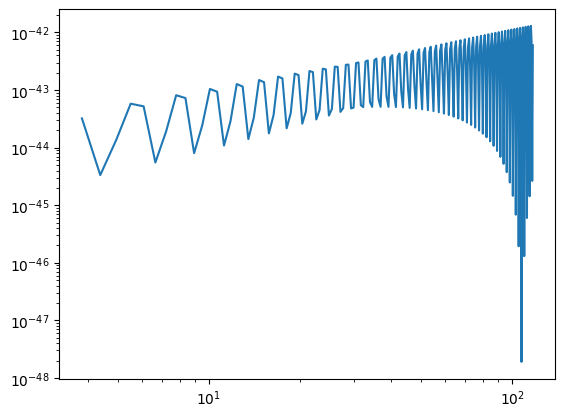

In [53]:
plt.plot(q_range, rates)
plt.yscale("log")
plt.xscale("log")

In [18]:
def q_integral_helper(q,n,j,m, const = v0**2*np.pi/(2*v_E*N0)):
    return structure_factor_and_inverse_mean(q,n,j,m,const)*q

In [19]:
def whole_q_integral(m_chi, n, j): 
    w_curr=n*w_minus+j*(w_plus-w_minus)
    root = m_chi**2*(v_esc+v_E)**2-2*w_curr*m_chi
    if root<0:
        return (0,0)
    bounds = [m_chi*(v_esc+v_E)-np.sqrt(root), 
          m_chi*(v_esc+v_E)+np.sqrt(root)]
    return scipy.integrate.quad(q_integral_helper, 
                                bounds[0], bounds[1], args = (n,j,m_chi), limit=100)

In [20]:
n = 1
j=0
w = n*w_minus+j*(w_plus-w_minus)
m_min = 2*w/(v_esc+v_E)**2
m_chi = m_min*2
m_range1 = np.linspace(m_min*0.5,m_min,200)
m_range2 = np.linspace(m_min, 5*m_min, 200)
q_range = np.linspace((m_chi*(v_esc+v_E)-np.sqrt(m_chi**2*(v_esc+v_E)**2-2*w*m_chi))*0.9
                      , m_chi*(v_esc+v_E)+np.sqrt(m_chi**2*(v_esc+v_E)**2-2*w*m_chi)*1.5, 200)

In [21]:
print(m_min)

19696.137326515705


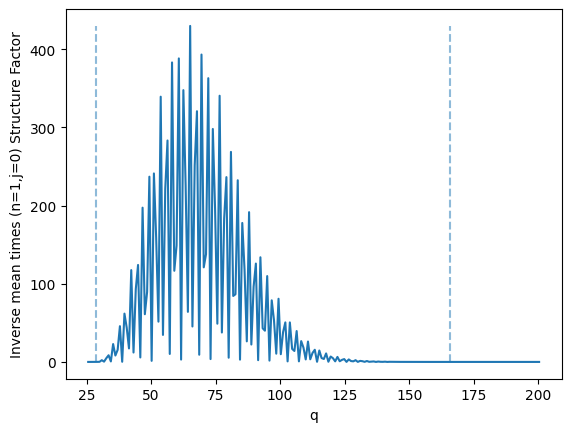

In [22]:
y = [structure_factor_and_inverse_mean(q, n,j, m_chi)*q for q in q_range]
plt.plot(q_range,y)
plt.ylabel("Inverse mean times (n=1,j=0) Structure Factor")
plt.xlabel("q")
root = m_chi**2*(v_esc+v_E)**2-2*w*m_chi
plt.vlines([m_chi*(v_esc+v_E)-np.sqrt(root), 
          m_chi*(v_esc+v_E)+np.sqrt(root)],0,max(y), linestyles="dashed", alpha=0.5)
plt.show()

In [23]:
I1 = [whole_q_integral(m, n, j) for m in m_range1]
I2 = [whole_q_integral(m, n, j) for m in m_range2]

In [24]:
I_int1 = [i[0] for i in I1]
I_error1 = [i[1] for i in I1]
I_int2 = [i[0] for i in I2]
I_error2 = [i[1] for i in I2]

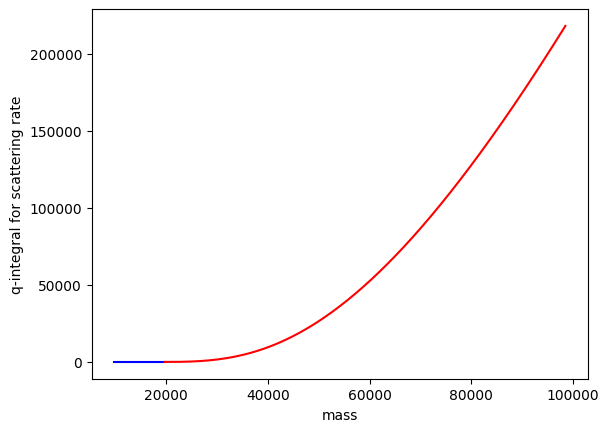

In [25]:
plt.plot(m_range1, I_int1, color="blue")
plt.plot(m_range2, I_int2, color="red")
plt.xlabel("mass")
plt.ylabel("q-integral for scattering rate")
plt.show()

In [26]:
def scatteringRate_pt1(m_chi, n,j):
    mu_X = reducedMass(m_chi, Si_nucleus_mass)
    const=dm_density/(target_density*mu_X**2*m_chi) #density units cancel, leaving mass and reduced mass units
    #const units: 1/(eV)^3
    return [const*inte for inte in whole_q_integral(m_chi,n,j)]

In [27]:
I1 = [scatteringRate_pt1(m,n,j) for m in m_range1]
I2 = [scatteringRate_pt1(m,n,j) for m in m_range2]

In [28]:
print(I2[100])

[7.371903138449441e-35, 2.40258168237951e-43]


In [29]:
I_int1 = [i[0] for i in I1]
I_error1 = [i[1] for i in I1]
I_int2 = [i[0] for i in I2]
I_error2 = [i[1] for i in I2]

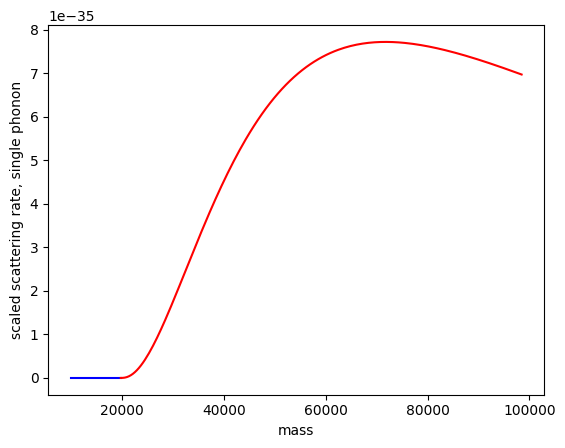

In [30]:
plt.plot(m_range1, I_int1, color="blue")
plt.plot(m_range2, I_int2, color="red")
plt.xlabel("mass")
plt.ylabel("scaled scattering rate, single phonon")
plt.show()

In [32]:
m_range = range(6000,300000,100)
n_val = [findMax_n(m) for m in m_range]

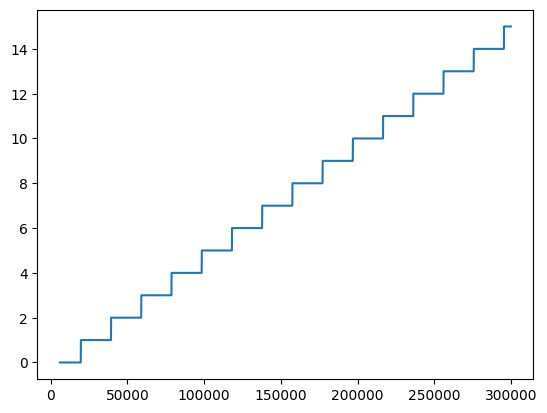

In [33]:
plt.plot(m_range, [findMax_n(m) for m in m_range])

In [34]:
def scatteringRate_tot(m_chi):
    n_max = findMax_n(m_chi)
    tot=0
    err=0
    for n in range(n_max+1):
        for j in range(n+1):
            result = scatteringRate_pt1(m_chi,n,j)
            tot += result[0]
            err+=result[1]
    return [tot,err]

In [35]:
scatteringRate1_data = [scatteringRate_tot(m) for m in m_range1]
scatteringRate2_data = [scatteringRate_tot(m) for m in m_range2]
scatteringRate1 = [i[0] for i in scatteringRate1_data]
scatteringRate2 = [i[0] for i in scatteringRate2_data]

In [36]:
print(scatteringRate1[10:15])

[4.021130748113937e-32, 3.994136015258342e-32, 3.9674266106466166e-32, 3.940998379569868e-32, 3.9148472416265507e-32]


Text(0, 0.5, 'full scaled scattering rate')

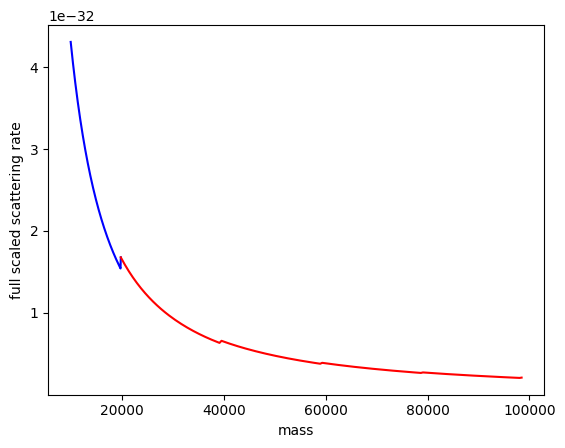

In [37]:
plt.plot(m_range1, scatteringRate1, color="blue")
plt.plot(m_range2, scatteringRate2, color="red")
plt.xlabel("mass")
plt.ylabel("full scaled scattering rate")

In [38]:
def crossSection_single_phonon(m_chi, n, j):
    conversion = 
    result = scatteringRate_pt1(m_chi, n,j)
    if result[0]==0:
        #print(m_chi)
        return [np.nan, np.nan]
    const =1161343322
    return [const/result[0], 1/(result[0]**2)*result[1]]

In [39]:
m_range = np.linspace(m_min*0.5, m_min*3,100)
cross_1_0 = [crossSection_single_phonon(m,1,0) for m in m_range]
cross_1_1 = [crossSection_single_phonon(m,1,1) for m in m_range]
cross_2_0 = [crossSection_single_phonon(m,2,0) for m in m_range]
cross_2_1 = [crossSection_single_phonon(m,2,1) for m in m_range]
cross_2_2 = [crossSection_single_phonon(m,2,2) for m in m_range]

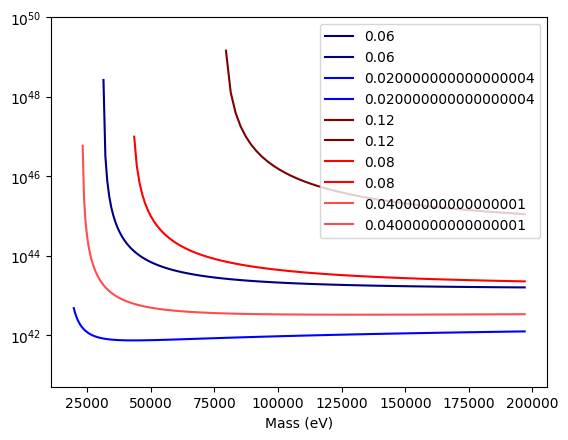

In [43]:
plt.plot(m_range, cross_1_0, color=(0,0,0.5), label=getOmega(1,0))
plt.plot(m_range, cross_1_1, color=(0,0,1), label=getOmega(1,1))
plt.plot(m_range, cross_2_0, color=(0.5,0,0), label=getOmega(2,0))
plt.plot(m_range, cross_2_1, color=(1,0,0), label=getOmega(2,1))
plt.plot(m_range, cross_2_2, color=(1,0.3,0.3), label=getOmega(2,2))
plt.ylim(5e40, 1e50)
plt.yscale("log")
#plt.legend()
#plt.xscale("log")
plt.legend()
plt.xlabel("Mass (eV)")
plt.show()

In [41]:
def crossSection_all(m_chi):
    result = scatteringRate_tot(m_chi)
    if result[0]==0:
        #print(m_chi)
        return [np.nan, np.nan]
    return [1/result[0], 1/(result[0]**2)*result[1]]    

In [42]:
log10m = np.linspace(np.log10(m_min), np.log10(m_min)+1,100)
m_range = 10**log10m
#m_range = np.linspace(m_min, m_min*5)
cross_all = [crossSection_all(m) for m in m_range]

/var/folders/ld/4n9y5rh93q58fgwgwnqf2w640000gn/T/ipykernel_22808/3370993783.py:8: IntegrationWarning: The maximum number of subdivisions (100) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return scipy.integrate.quad(q_integral_helper,


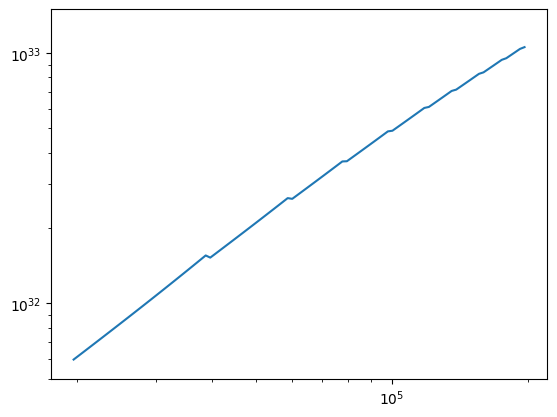

In [64]:
plt.plot(m_range, cross_all)
plt.ylim(5e31, 1.5e33)
plt.yscale("log")
plt.xscale("log")